In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import NearestNeighbors

In [61]:
df_cluster = pd.read_parquet('../../data/processed/real_used/data_phase2_clustering.parquet')
df_raw_parquet= pd.read_parquet('../../data/processed/real_used/transactions.parquet')
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   oldbalanceOrg          float64
 2   oldbalanceDest         float64
 3   errorBalanceOrig       float64
 4   errorBalanceDest       float64
 5   balance_drain_ratio    float64
 6   hour_of_day            float64
 7   type_CASH_IN           float64
 8   type_CASH_OUT          float64
 9   type_DEBIT             float64
 10  type_PAYMENT           float64
 11  type_TRANSFER          float64
 12  has_zero_orig_balance  float64
dtypes: float64(13)
memory usage: 631.1 MB


### Eksplorasi Pra Clustering

In [62]:
var_analysis = pd.DataFrame({
    'feature': df_cluster.columns,
    'variance': df_cluster.var().values,
    'std': df_cluster.std().values,
    'mean': df_cluster.mean().values
})
print("Variance Analysis:")
print(var_analysis)

Variance Analysis:
                  feature       variance         std        mean
0                  amount       9.557044    3.091447    0.537495
1           oldbalanceOrg     724.344362   26.913646    7.638017
2          oldbalanceDest      12.992453    3.604505    1.026467
3        errorBalanceOrig       1.229216    1.108700   -0.497293
4        errorBalanceDest  338966.981535  582.208710  244.845470
5     balance_drain_ratio       2.633824    1.622906    0.921286
6             hour_of_day       0.381183    0.617400   -0.096935
7            type_CASH_IN       0.171557    0.414194    0.219923
8           type_CASH_OUT       0.227996    0.477490    0.351663
9              type_DEBIT       0.006469    0.080432    0.006512
10           type_PAYMENT       0.223803    0.473079    0.338146
11          type_TRANSFER       0.076741    0.277022    0.083756
12  has_zero_orig_balance       0.221249    0.470371    0.330438


### Dimensionality Reduction

Variance explained by PC1-PC5: [0.99820254 0.9999249  0.99996612 0.99998676 0.99999459]
Variance untuk 95% coverage: 1 komponen


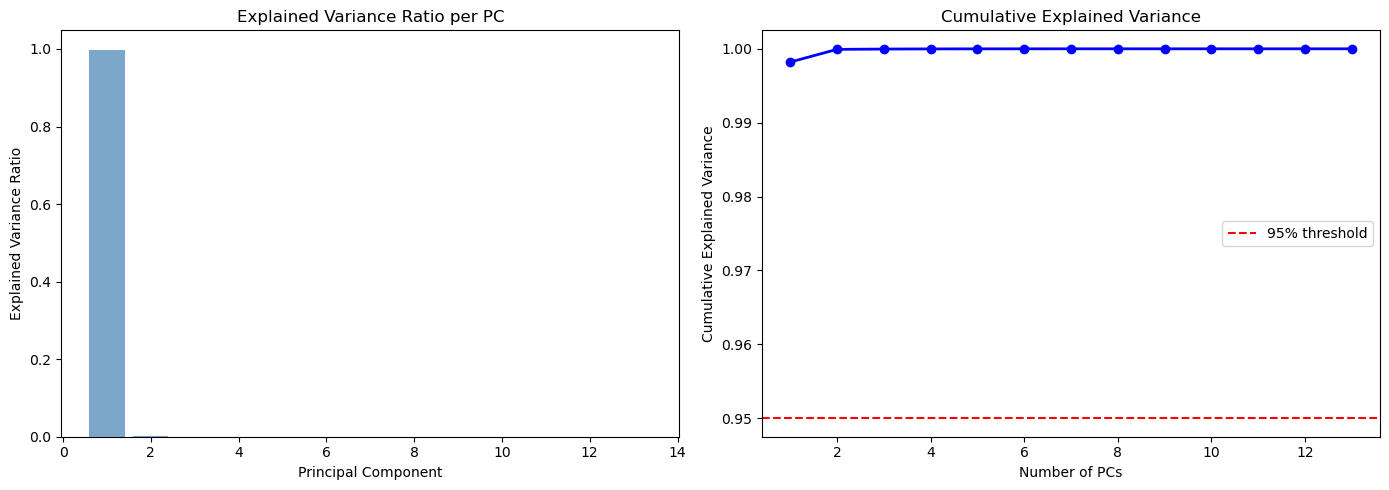

In [63]:
pca_full = PCA(n_components=min(13, df_cluster.shape[1]))

SAMPLE_SIZE_PCA = 200_000
idx_pca = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_PCA, replace=False)
X_pca_fit = df_cluster.values[idx_pca]
pca_full.fit(X_pca_fit)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Variance explained by PC1-PC5: {explained_var[:5]}")
print(f"Variance untuk 95% coverage: {np.argmax(explained_var >= 0.95) + 1} komponen")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Explained Variance Ratio per PC')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(explained_var)+1), explained_var, 'bo-', linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

In [64]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca_fit)
print(f"\nPCA 2D explained variance: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")


PCA 2D explained variance: 100.0%


In [65]:
pca_5d = PCA(n_components=5)
X_5d = pca_5d.fit_transform(df_cluster.values[idx_pca])

### Kmeans - Elbow Method & Silhoutte Score

  K=2: Inertia=5012309169, Silhouette=0.9242, Davies-Bouldin=0.1535
  K=3: Inertia=397592914, Silhouette=0.9656, Davies-Bouldin=0.0880
  K=4: Inertia=230363672, Silhouette=0.8763, Davies-Bouldin=0.4363
  K=5: Inertia=180518465, Silhouette=0.8534, Davies-Bouldin=0.5425
  K=6: Inertia=145960091, Silhouette=0.8409, Davies-Bouldin=0.6769
  K=7: Inertia=119684463, Silhouette=0.8487, Davies-Bouldin=0.6570
  K=8: Inertia=99553631, Silhouette=0.8397, Davies-Bouldin=0.6579
  K=9: Inertia=86753654, Silhouette=0.8401, Davies-Bouldin=0.6470
  K=10: Inertia=75963017, Silhouette=0.8335, Davies-Bouldin=0.6753


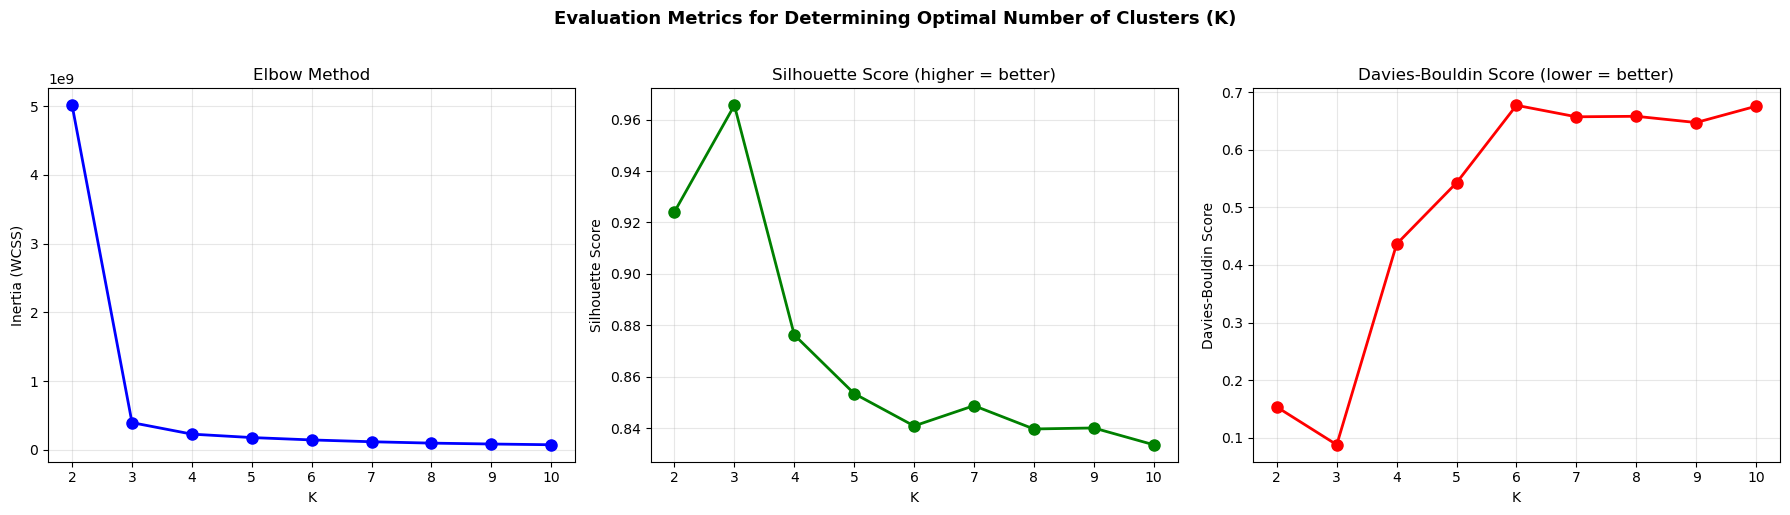

In [66]:
SAMPLE_SIZE_K = 100_000
idx_k = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_K, replace=False)
X_sample_k = df_cluster.values[idx_k]

K_range = range(2, 11)
inertias = []
sil_scores = []
db_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample_k)
    inertias.append(km.inertia_)
    
    sub_idx = np.random.RandomState(42).choice(SAMPLE_SIZE_K, min(20000, SAMPLE_SIZE_K), replace=False)
    sil = silhouette_score(X_sample_k[sub_idx], labels[sub_idx])
    sil_scores.append(sil)
    db = davies_bouldin_score(X_sample_k[sub_idx], labels[sub_idx])
    db_scores.append(db)
    print(f"  K={k}: Inertia={km.inertia_:.0f}, Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")

optimal_sil_k = K_range[np.argmax(sil_scores)]
optimal_db_k = K_range[np.argmin(db_scores)]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (higher = better)', fontsize=12)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

axes[2].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontsize=12)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(alpha=0.3)

plt.suptitle(
    "Evaluation Metrics for Determining Optimal Number of Clusters (K)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### K-Means Final All Data

In [67]:
OPTIMAL_K = 3
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=500)
kmeans_labels = kmeans_final.fit_predict(df_cluster.values)

df_cluster['cluster_kmeans'] = kmeans_labels
print(f"Distribusi klaster:\n{pd.Series(kmeans_labels).value_counts().sort_index()}")

Distribusi klaster:
0    4691720
1    1470126
2     200774
Name: count, dtype: int64


### DBSCAN

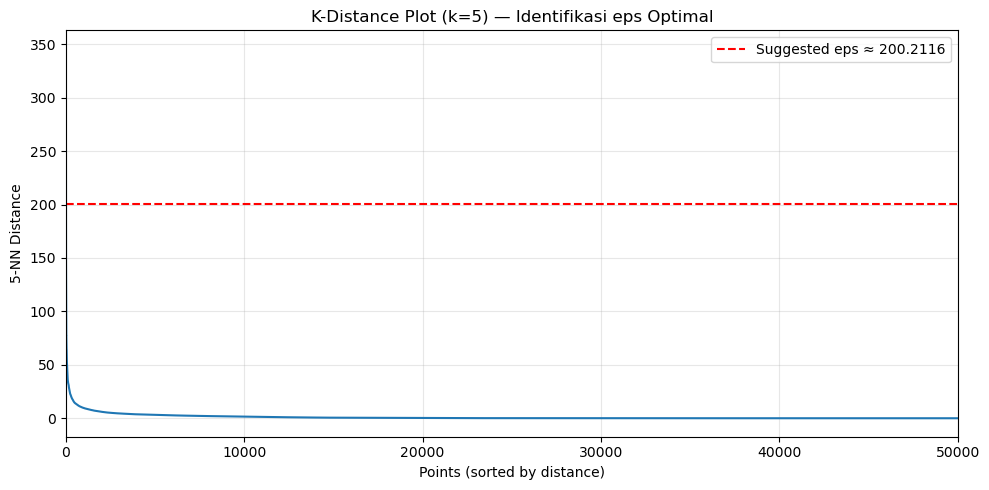


Suggested eps dari k-distance plot: 200.21156191043497


In [68]:
SAMPLE_SIZE_DBSCAN = 50_000
idx_dbscan = np.random.RandomState(42).choice(X_5d.shape[0], SAMPLE_SIZE_DBSCAN, replace=False)
X_dbscan = X_5d[idx_dbscan]

k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='ball_tree').fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, linewidth=1.5)
ax.set_title(f'K-Distance Plot (k={k_neighbors}) — Identifikasi eps Optimal', fontsize=12)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_neighbors}-NN Distance')
ax.set_xlim(0, len(k_distances))
ax.grid(alpha=0.3)

knee_idx = np.argmax(np.diff(np.diff(k_distances))) + 2
eps_suggestion = k_distances[knee_idx]
ax.axhline(y=eps_suggestion, color='red', linestyle='--', label=f'Suggested eps ≈ {eps_suggestion:.4f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nSuggested eps dari k-distance plot: {eps_suggestion}")

In [69]:
k_distances = np.sort(distances[:, -1])[::-1]
k_distances_ascending = np.sort(distances[:, -1])

eps_p75 = np.percentile(k_distances_ascending, 75)
eps_p80 = np.percentile(k_distances_ascending, 80)
eps_p85 = np.percentile(k_distances_ascending, 85)

print(f"--- ANALISIS PERSENTIL K-DISTANCE ---")
print(f"Jarak pada Persentil ke-75 (Ambang Batas Ketat) : {eps_p75:.4f}")
print(f"Jarak pada Persentil ke-80 (Ambang Batas Siku)  : {eps_p80:.4f}")
print(f"Jarak pada Persentil ke-85 (Ambang Batas Longgar): {eps_p85:.4f}")

--- ANALISIS PERSENTIL K-DISTANCE ---
Jarak pada Persentil ke-75 (Ambang Batas Ketat) : 0.9166
Jarak pada Persentil ke-80 (Ambang Batas Siku)  : 1.4514
Jarak pada Persentil ke-85 (Ambang Batas Longgar): 2.1872


In [70]:
EPS = eps_p85
MIN_SAMPLES = 50

print(f"\n=== DBSCAN: eps={EPS:.4f}, min_samples={MIN_SAMPLES} ===")
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, algorithm='ball_tree', n_jobs=-1)
dbscan_labels_sample = dbscan.fit_predict(X_dbscan)

n_clusters_dbscan = len(set(dbscan_labels_sample)) - (1 if -1 in dbscan_labels_sample else 0)
n_noise = (dbscan_labels_sample == -1).sum()
print(f"Number of Clusters Found: {n_clusters_dbscan}")
print(f"Number of Noise Points: {n_noise:,} ({n_noise/SAMPLE_SIZE_DBSCAN*100:.1f}%)")
print(f"\nCluster Distribution:\n{pd.Series(dbscan_labels_sample).value_counts()}")


=== DBSCAN: eps=2.1872, min_samples=50 ===
Number of Clusters Found: 10
Number of Noise Points: 12,914 (25.8%)

Cluster Distribution:
 0    36161
-1    12914
 2      231
 1      128
 3      116
 8      113
 6       88
 7       83
 4       66
 9       53
 5       47
Name: count, dtype: int64



Proyeksi PCA 2D untuk visualisasi sebaran DBSCAN...


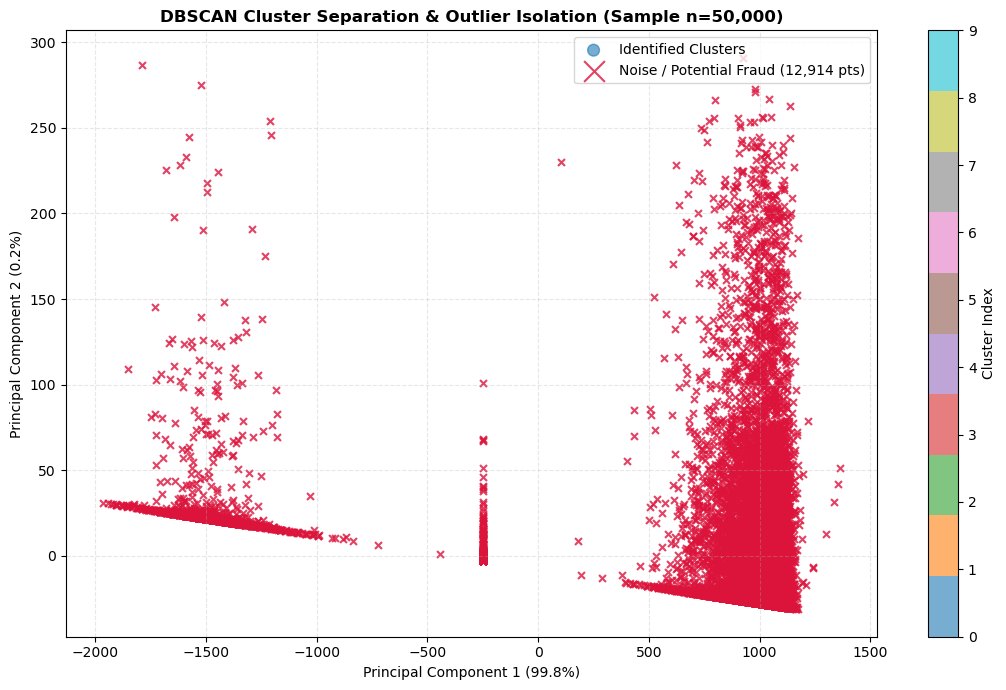

In [71]:
print("\nProyeksi PCA 2D untuk visualisasi sebaran DBSCAN...")
pca_dbscan = PCA(n_components=2)
X_dbscan_2d = pca_dbscan.fit_transform(X_dbscan)

fig, ax = plt.subplots(figsize=(11, 7))

mask_clusters = dbscan_labels_sample >= 0
scatter = ax.scatter(
    X_dbscan_2d[mask_clusters, 0], 
    X_dbscan_2d[mask_clusters, 1],
    c=dbscan_labels_sample[mask_clusters], 
    cmap="tab10", 
    s=8, 
    alpha=0.6,
    label="Identified Clusters"
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(n_clusters_dbscan))
cbar.set_label('Cluster Index')

mask_noise = dbscan_labels_sample == -1
if mask_noise.sum() > 0:
    ax.scatter(
        X_dbscan_2d[mask_noise, 0], 
        X_dbscan_2d[mask_noise, 1],
        c="crimson", 
        marker="x", 
        s=25, 
        alpha=0.8, 
        label=f"Noise / Potential Fraud ({n_noise:,} pts)"
    )

ax.set_title(f"DBSCAN Cluster Separation & Outlier Isolation (Sample n={SAMPLE_SIZE_DBSCAN:,})", fontsize=12, fontweight='bold')
ax.set_xlabel(f"Principal Component 1 ({pca_dbscan.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca_dbscan.explained_variance_ratio_[1]*100:.1f}%)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper right", markerscale=3)
plt.tight_layout()
plt.show()

### Hierarchical Clustering


=== HIERARCHICAL CLUSTERING (sample n=5,000) ===


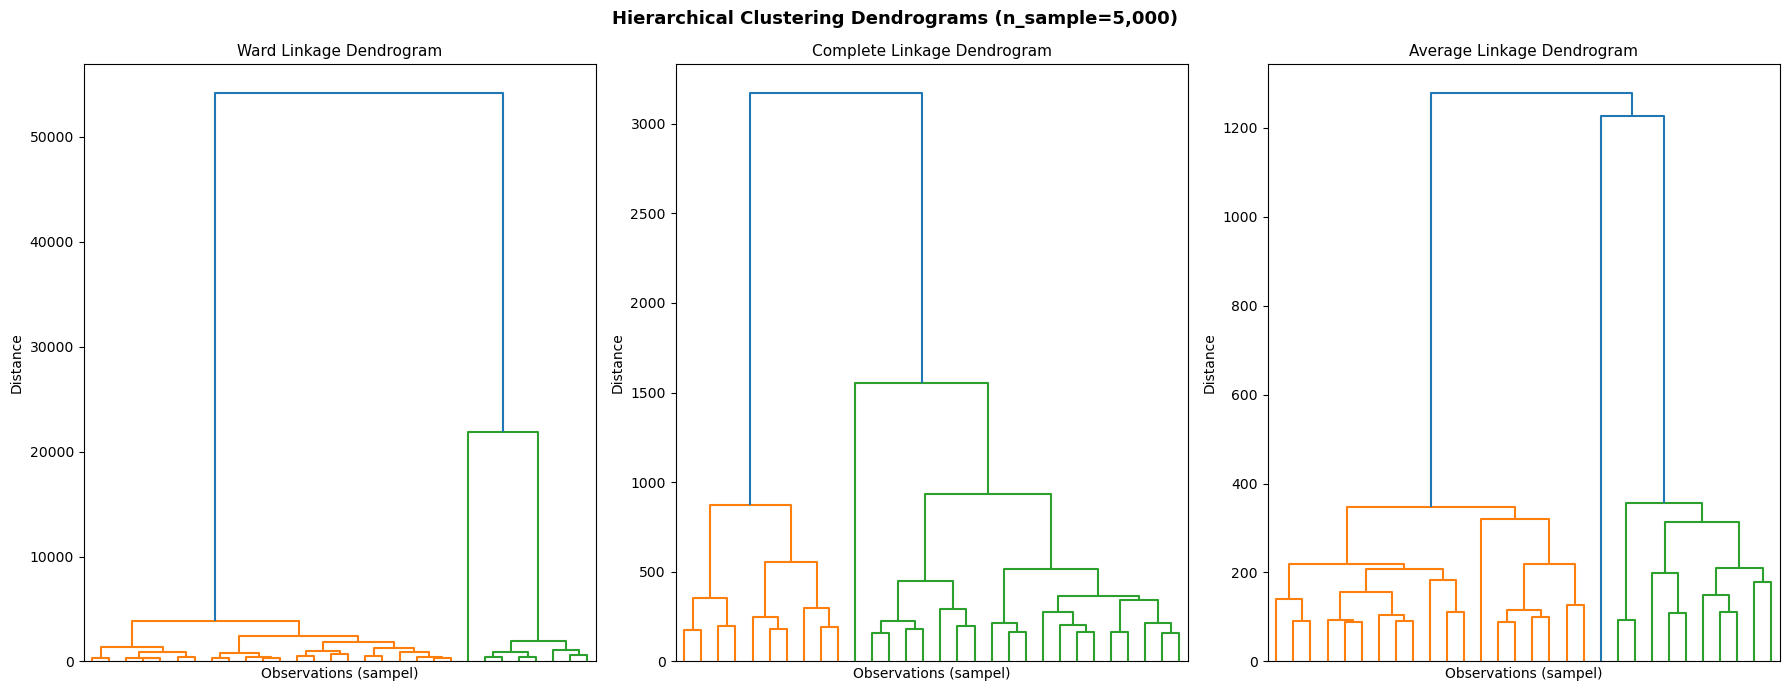

In [72]:
SAMPLE_SIZE_HIER = 5_000
idx_hier = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_HIER, replace=False)
X_hier = df_cluster.values[idx_hier]

print(f"\n=== HIERARCHICAL CLUSTERING (sample n={SAMPLE_SIZE_HIER:,}) ===")

linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, method in enumerate(linkage_methods):
    Z = linkage(X_hier, method=method)
    dendrogram(
        Z, ax=axes[i],
        truncate_mode='lastp', p=30,
        show_leaf_counts=True,
        no_labels=True,
        color_threshold=0.7 * max(Z[:, 2])
    )
    axes[i].set_title(f'{method.capitalize()} Linkage Dendrogram', fontsize=11)
    axes[i].set_xlabel('Observations (sampel)')
    axes[i].set_ylabel('Distance')

plt.suptitle(f'Hierarchical Clustering Dendrograms (n_sample={SAMPLE_SIZE_HIER:,})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
# Agglomerative clustering dengan K dari Elbow
hier_cluster = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels_sample = hier_cluster.fit_predict(X_hier)
print(f"Hierarchical cluster distribution (sample):\n{pd.Series(hier_labels_sample).value_counts()}")

Hierarchical cluster distribution (sample):
2    3656
0    1178
1     166
Name: count, dtype: int64


### Cluster Profilling

In [74]:
df_raw_parquet.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0



Cluster Profile Table:
         n_records    mean_amount  median_amount  mean_balance_orig  \
cluster                                                               
0          4691720  168551.484375       36657.49       5.605400e+04   
1          1470126  181567.781250      147139.35       3.337206e+06   
2           200774  431674.531250      172244.16       6.802581e+05   

         mean_balance_dest  mean_drain_ratio  mean_error_orig  \
cluster                                                         
0                920650.75              2.02    150069.671875   
1               1558698.25              2.36    333928.687500   
2               1954576.75              2.73    420735.625000   

         mean_error_dest dominant_type  
cluster                                 
0                0.04000       PAYMENT  
1           303681.71875       CASH_IN  
2          -602623.81250      CASH_OUT  


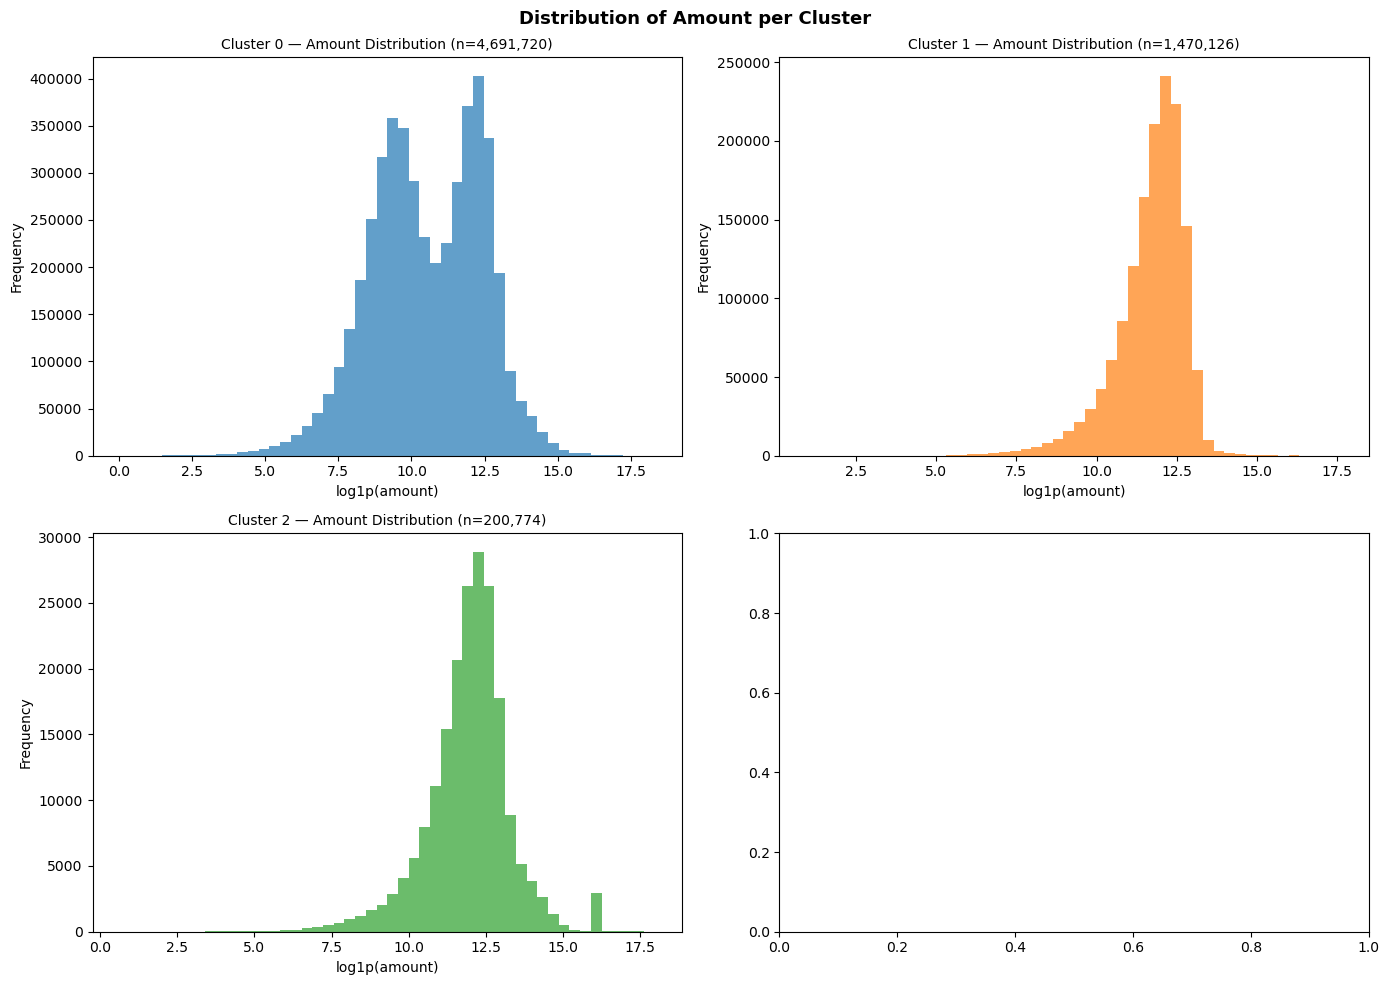

In [75]:
# Gabungkan hasil K-Means dengan data asli
df_profile = df_raw_parquet.copy()
df_profile['cluster'] = kmeans_labels

# Hitung engineered features untuk profiling
df_profile['errorBalanceOrig'] = df_profile['newbalanceOrig'] + df_profile['amount'] - df_profile['oldbalanceOrg']
df_profile['balance_drain_ratio'] = np.where(
    df_profile['oldbalanceOrg'] > 0,
    (df_profile['amount'] / df_profile['oldbalanceOrg']).clip(0, 10),
    0
)
df_profile['is_merchant_dest'] = df_profile['nameDest'].str.startswith('M').astype(int)
df_profile['errorBalanceDest'] = np.where(
    df_profile['is_merchant_dest'] == 1, 0,
    df_profile['oldbalanceDest'] + df_profile['amount'] - df_profile['newbalanceDest']
)

# Profile numerik
profile_num = df_profile.groupby('cluster').agg(
    n_records=('amount', 'count'),
    mean_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    mean_balance_orig=('oldbalanceOrg', 'mean'),
    mean_balance_dest=('oldbalanceDest', 'mean'),
    mean_drain_ratio=('balance_drain_ratio', 'mean'),
    mean_error_orig=('errorBalanceOrig', 'mean'),
    mean_error_dest=('errorBalanceDest', 'mean'),
).round(2)

# Dominant transaction type per cluster
dominant_type = df_profile.groupby('cluster')['type'].agg(
    lambda x: x.value_counts().index[0]
).rename('dominant_type')

profile_full = profile_num.join(dominant_type)
print("\nCluster Profile Table:")
print(profile_full)

# Visualisasi distribusi amount per cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for c in range(OPTIMAL_K):
    data_c = df_profile[df_profile['cluster'] == c]['amount']
    axes[c].hist(np.log1p(data_c), bins=50, color=f'C{c}', alpha=0.7, edgecolor='none')
    axes[c].set_title(f'Cluster {c} — Amount Distribution (n={len(data_c):,})', fontsize=10)
    axes[c].set_xlabel('log1p(amount)')
    axes[c].set_ylabel('Frequency')

plt.suptitle('Distribution of Amount per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

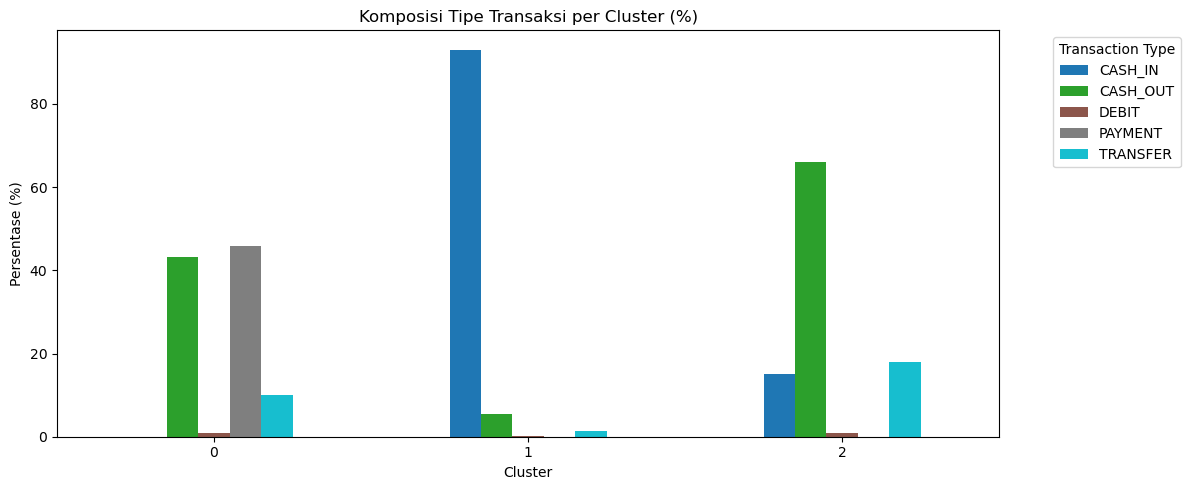

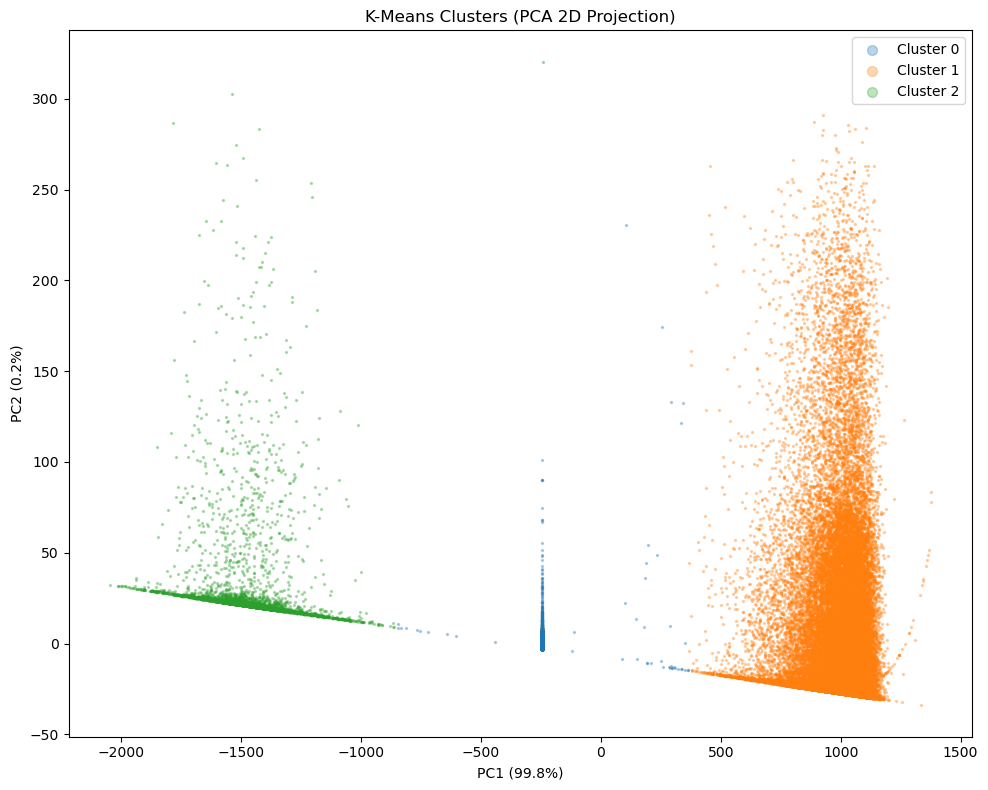

In [76]:
# Tipe transaksi per cluster
type_by_cluster = pd.crosstab(df_profile['cluster'], df_profile['type'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(12, 5))
type_by_cluster.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Komposisi Tipe Transaksi per Cluster (%)', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Persentase (%)')
ax.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Visualisasi 2D PCA
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['C0', 'C1', 'C2', 'C3']
for c in range(OPTIMAL_K):
    mask = kmeans_labels[idx_pca] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=2, alpha=0.3, color=colors[c], label=f'Cluster {c}')
ax.set_title('K-Means Clusters (PCA 2D Projection)', fontsize=12)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()